# Кластерный анализ


### Следующий код выполняет три основных шага.
    1. Рассчитывает расстояние до ближайшего соседа между всеми событиями в каталоге.
    2. Разделяет каталог сейсмичности на семейства и независимые фоновые события на основе порогового значения ближайшего соседа.
    3. Подсчитывает количество афтершоков для каждого семейства и строит график зависимости количества афтершоков от магнитуды главного толчка.

### 0: Карта сейсмичности
Загрузка каталога сейсмичности и построение карты с помощью Basemap (этот шаг можно пропустить, если модуль базовой карты mpl не установлен)

In [1]:
# -------------------------------------------------------------------------------
# Указание файла данных, времени и диапазона величин
# -------------------------------------------------------------------------------

dir_in = '../data'
# Файл создается с помощью: 1_create_mat_eqCat_file.ipynb
file_in = 'NEIC_Global_Chignik_2021.mat'
# completeness magntiude = Mmin, and Mmax (не обязательно указывать)
Mmin, Mmax = 3, None
tmin, tmax = 1900, 2025

In [2]:
# Импорт внешних библиотек
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os
import scipy.io

# Импорт внутренних модулей
from src.EqCat import EqCat # EqCat — объект Python, который используется для обработки каталогов
from src import clustering
eqCat = EqCat()

# -------------------------------------------------------------------------------
# Загрузка данных с первичной фильтрацией
# -------------------------------------------------------------------------------

eqCat.loadMatBin(f"{dir_in}/{file_in}")
print('Всего событий —', eqCat.size())
eqCat.selectEvents(Mmin, Mmax, 'Mag')
eqCat.selectEvents(tmin, tmax, 'Time')
print('Всего событий после фитрации по магнитуде и времени —', eqCat.size())

Всего событий — 15
Всего событий после фитрации по магнитуде и времени — 15


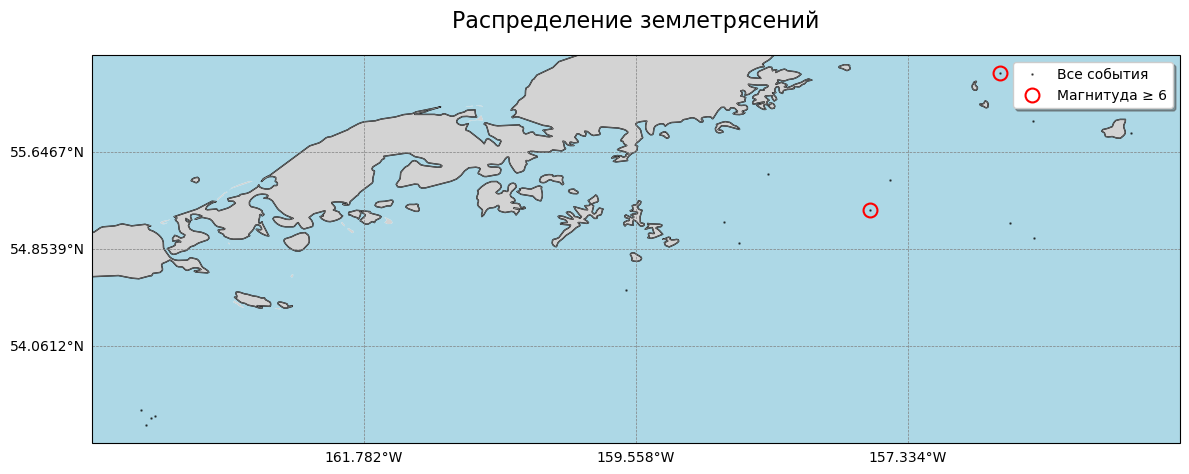

In [3]:
if hasattr(eqCat, 'data') and all(key in eqCat.data for key in ['Lon', 'Lat', 'Mag']):
    # Определение границы карты на основе данных
    projection = ccrs.PlateCarree()
    xmin, xmax = eqCat.data['Lon'].min(), eqCat.data['Lon'].max()
    ymin, ymax = eqCat.data['Lat'].min(), eqCat.data['Lat'].max()

    # Добавление отступов для лучшего отображения
    margin_x = (xmax - xmin) * 0.05
    margin_y = (ymax - ymin) * 0.05
    xmin, xmax = xmin - margin_x, xmax + margin_x
    ymin, ymax = ymin - margin_y, ymax + margin_y

    # Настройка фигуры и оси с проекцией PlateCarree
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=projection)
    ax.set_extent([xmin, xmax, ymin, ymax], crs=projection)

    # Добавление элементов карты
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')

    # Отрисовка всех событий как чёрных точек
    ax.plot(eqCat.data['Lon'], eqCat.data['Lat'], 'ko', markersize=0.8, alpha=0.6, label='Все события', transform=projection)

    # Выделение событий с магнитудой >= 6 красными окружностями
    sel6 = eqCat.data['Mag'] >= 6
    ax.plot(eqCat.data['Lon'][sel6], eqCat.data['Lat'][sel6], 'ro', markersize=10, markeredgewidth=1.5, mfc='none', label='Магнитуда ≥ 6', transform=projection)

    # Добавление меридиан и параллелей
    meridians = np.linspace(xmin, xmax, 5)
    parallels = np.linspace(ymin, ymax, 5)
    gl = ax.gridlines(
        xlocs=meridians, ylocs=parallels, 
        draw_labels={'bottom': 'x', 'left': 'y'},  # Метки только снизу (x) и слева (y)
        linewidth=0.5, color='gray', linestyle='--'
    )

    # НаНастройка стиля меток
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    # Добавление заголовка и легенды
    plt.title('Распределение землетрясений', fontsize=16, pad=20)
    plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

    # Отображение
    plt.tight_layout()
    plt.show()
else:
    print("Не удалось отобразить график: данные в eqCat.data отсутствуют или неполные.")

### 1: Вычисление расстояний до ближайших соседей

Диапазон глубин: от 6.8 до 51.6 (км)
Сохранение файла: data/NEIC_Global_Chignik_2021_NND_Mc_3.0.mat
Загружаем eta_0 из файла data/NEIC_Global_Chignik_2021.mat_Mc_3.0_eta_0.txt
eta_0 = -2.997


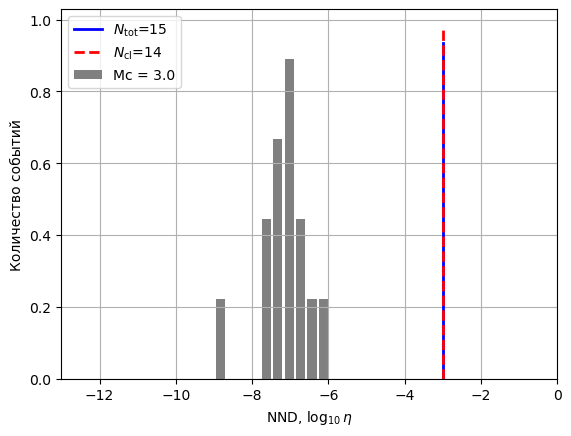

In [4]:
# Установка параметров
dPar = {
    'D': 1.6,                 # TODO: необходимы реальные значения, полученные из анализа
    'b': 1.3333398574492394,  # b-значение, вычисляется с помощью специального инструмента
    'Mc': Mmin,               # пороговая магнитуда (минимальная магнитуда, выше которой данные полны)
    'eta_binsize': 0.3,       # размер ячейки гистограммы по логарифмической шкале расстояний
    'xmin': -13,              # минимальное значение по оси X (логарифм расстояния)
    'xmax': 0                 # максимальное значение по оси X
}

# ---------------------------------------------------------------------------------------------------------
# Подготовка данных
# ---------------------------------------------------------------------------------------------------------

# Добавление глубины как координаты Z
eqCat.data['Z'] = eqCat.data['Depth']
print('Диапазон глубин: от', eqCat.data['Z'].min(), 'до', eqCat.data['Z'].max(), '(км)')

# ---------------------------------------------------------------------------------------------------------
# Вычисление расстояний в пространстве-времени-магнитуде (NND, ближайший сосед)
# ---------------------------------------------------------------------------------------------------------

# Вычисление расстояния до ближайшего соседа (NND) в масштабированном пространстве
dNND = clustering.NND_eta(eqCat, dPar, correct_co_located=True, verbose=True)

# Построение гистограммы логарифмов расстояний до ближайшего соседа
aBins = np.arange(-13, 1, dPar['eta_binsize'], dtype=float)  # создание массива границ ячеек
aHist, aBins = np.histogram(np.log10(dNND['aNND'][dNND['aNND'] > 0]), aBins)  # гистограмма

# Центирование ячейки (по середине интервала)
aBins = aBins[:-1] + dPar['eta_binsize'] * 0.5

# Корекция гистограммы на размер ячейки (чтобы получить плотность)
aHist = aHist / dPar['eta_binsize']

# Нормирование на общее количество событий → выводим оценку плотности вероятности (PDF)
aHist /= eqCat.size()

# ---------------------------------------------------------------------------------------------------------
# Сохранение результатов
# ---------------------------------------------------------------------------------------------------------

# Сохранение данных в формат .mat (MATLAB)
NND_file = f"data/{file_in.split('.')[0]}_NND_Mc_{dPar['Mc']:.1f}.mat"
print('Сохранение файла:', NND_file)

# Сохранение словаря dNND (включая расстояния до соседей) в .mat-файл с сжатием
scipy.io.savemat(NND_file, dNND, do_compression=True)

# ---------------------------------------------------------------------------------------------------------
# Построение гистограммы
# ---------------------------------------------------------------------------------------------------------

# Загрузка значения eta_0 (характерное расстояние, связанное с кластеризацией)
eta_0_file = f"data/{file_in}_Mc_{dPar['Mc']:.1f}_eta_0.txt"

if os.path.isfile(eta_0_file):
    print('Загружаем eta_0 из файла', eta_0_file)
    f_eta_0 = np.loadtxt(eta_0_file, dtype=float)  # читаем значение eta_0
    print('eta_0 =', f_eta_0)
else:
    # Если файл не найден — используем значение по умолчанию
    f_eta_0 = -5
    print('Файл с eta_0 не найден:', eta_0_file, '— используем значение по умолчанию:', f_eta_0)

# Создание графика
fig, ax = plt.subplots()

# Построение гистограммы как столбчатой диаграммы
ax.bar(aBins, aHist,
       width=0.8 * dPar['eta_binsize'],  # ширина столбцов
       align='edge',                     # выравнивание по краю
       color='.5',                       # серый цвет
       label='Mc = %.1f' % dPar['Mc'])   # подпись: пороговая магнитуда

# Вертикальная синяя линия — общее количество событий (N_tot)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'b-', lw=2,
        label=r'$N_\mathrm{tot}$=%i' % eqCat.size())

# Вертикальная красная пунктирная линия — количество кластерных событий (N_cl)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'r--', lw=2,
        label=r'$N_\mathrm{cl}$=%i' % dNND['aNND'][dNND['aNND'] < 1e-5].shape[0])

# Размещаем легенду в верхнем левом углу
ax.legend(loc='upper left')

# Подписи осей
ax.set_xlabel(r'NND, $\log_{10} \eta$')  # NND — расстояние до ближайшего соседа
ax.set_ylabel('Количество событий')

# Включаем сетку
ax.grid(True)

# Устанавливаем пределы по оси X
ax.set_xlim(dPar['xmin'], dPar['xmax'])

# Отображаем график
plt.show()

На рисунке выше показана гистограмма ближайших расстояний между исходными землетрясениями в каталоге (пространство-время-магнитуда).

Стоит обратить внимание на то, что в типичном каталоге землетрясений возникают два различных режима: кластерный режим (слева) и фоновый режим (справа). Первый режим представляет собой кластеризацию типа Омори (обычно «ближе»), а второй — фоновый пуассоновский процесс. Землетрясения в фоновом режиме — это землетрясения, которые, как можно наблюдать, не вызваны предыдущим землетрясением. $\eta_0$ — это пороговое значение между этими двумя режимами. На практике это приведёт к удалению всех связей между землетрясениями, превышающими это пороговое значение, и формированию отдельных кластеров землетрясений.

Для быстрого анализа можно просто выбрать значение, разделяющее эти режимы. Меньшие значения приведут к меньшим кластерам, большие — к более обширным кластерам, но могут включать фоновую сейсмичность.

### 2: Отделение кластеров от независимого фона и составление семейств событий

In [5]:
dPar['eta_0'] = f_eta_0
print('Порог сходства', dPar['eta_0'])

Порог сходства -2.997


In [6]:
clust_file = file_in.replace('all.mat', f'Mc_{dPar["Mc"]:.1f}_clusters.mat')
    
dNND['aNND'] = np.log10(dNND['aNND'])
# Кластеризация по критериям сходства eta_0
dClust = clustering.compileClust( dNND, f_eta_0, useLargerEvents = False)
# ---------------------------------------------------------------------------------------------------------
# Сохранение результатов
# ---------------------------------------------------------------------------------------------------------
scipy.io.savemat(os.path.join( dir_in,clust_file), dClust, do_compression=True)


Предполагается, что порог (-2.997) — это МАКСИМУМ, выбираем значения схожести НИЖЕ этого порога
---------compileClust - начальные числа:------
Количество одиночных: 0
Количество триггерных: 14, 14,
Общее количество: 14 14
Количество ID событий в нескольких кластерах: 0
Начальные одиночные события, ставшие родительскими - удаляем из dClust['0']:  0
---------------Итоговый результат--------------------------
Общее количество в кластерах: 15
Количество родителей (=количество кластеров): 1,
Количество одиночных: 0, Общее количество потомков (включая дубликаты):  14
Доля триггерных:  1.0 Доля главных толчков:  0.07 Одиночные:  0.0
Общее количество в каталоге:  15
Триггерные + одиночные 15


### Создание тестовых графиков для проверки работоспособности.
Первый график даёт приблизительный обзор кластерных и независимых событий в области пространства-времени с изменённым масштабом.

Это обеспечивает визуализацию кластерного поведения, описанного выше. На этот раз в нормализованном пространственном расстоянии ($R_{ij}$) в сравнении с нормализованным временным расстоянием ($T_{ij}$). Где:

$$ R_{ij} = r_{ij}^d\times10^{bM_i/2} $$
$$ T_{ij} = t_{ij}\times10^{bM_i/2} $$

Размер каталога потомков 14
Размер каталога родителей 14
Проверка, является ли интеграл ~1 1.0


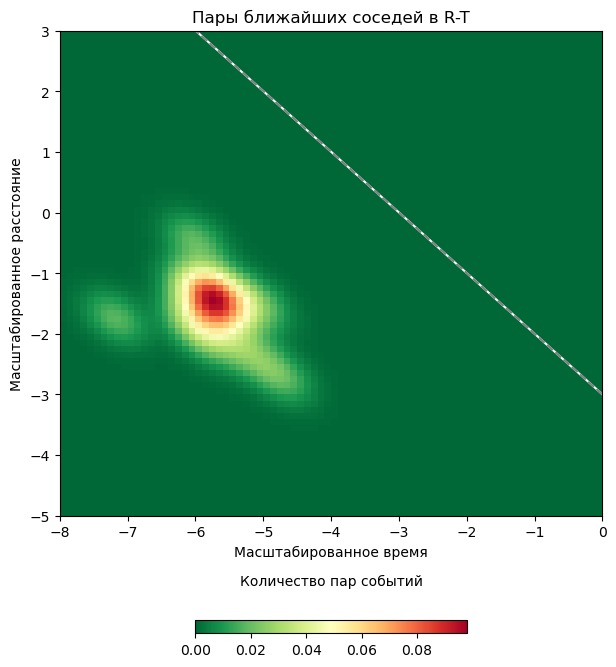

In [7]:
# Плотность пар событий в r-T
# ------------------------------------------------------------------
catChild = EqCat()
catParent = EqCat()
catChild.copy(eqCat)
catParent.copy(eqCat)
catChild.selEventsFromID(dNND['aEqID_c'], repeats=True)
catParent.selEventsFromID(dNND['aEqID_p'], repeats=True)
print('Размер каталога потомков', catChild.size()),  
print('Размер каталога родителей', catParent.size())  
# Вычисление масштабированных межсобытийных времен и расстояний
a_R, a_T = clustering.rescaled_t_r(catChild, catParent, dPar)
# Построение графика плотности пар событий 
fig = clustering.plot_R_T( a_T, a_R, f_eta_0)


1. **Оси**:
   - **X-ось (Rescaled Time)**: Масштабированное время (log10(a_T)), где `a_T` — это разница во времени между родительским и дочерним событиями, скорректированная с учётом магнитуды и параметров каталога (b-значение и фрактальная размерность D). Это отражает, насколько быстро происходят афтершоки относительно основного толчка.
   - **Y-ось (Rescaled Distance)**: Масштабированное расстояние (log10(a_R)), где `a_R` — это пространственное расстояние между событиями, также скорректированное с учётом параметров (обычно в километрах, преобразованное через фрактальную размерность).

2. **Цветовая карта (Density Plot)**:
   - График использует двумерную плотность событий (`normZZ`), вычисленную функцией `data_utils.density_2D`. Чем ярче цвет (например, зелёный или жёлтый по схеме `RdYlGn_r`), тем выше концентрация пар событий в данной области.
   - `normZZ` нормализуется на общее количество событий и размер ячеек (`binx * biny * eqCatMc.size()`), чтобы отразить количество пар событий на единицу площади.

3. **Линия разделения (eta_0)**:
   - На графике рисуются две линии:
     - Твёрдая белая линия (`'-', lw=1.5, color='w'`) и пунктирная серая линия (`'--', lw=1.5, color='.5'`) на уровне `f_eta_0`.
     - Эти линии представляют границу между кластерными (ниже порога) и фоновыми (выше порога) событиями. События ниже этой линии считаются связанными (например, афтершоками), а выше — независимыми.

- **Распределение кластеров**: График показывает, как пары событий группируются во времени и пространстве после масштабирования. Кластерные события (афтершоки) обычно сосредоточены в нижней левой части (близкие времена и расстояния), тогда как фоновые события распределены более равномерно.
- **Порог eta_0**: Значение `eta_0` используется для разделения. Если логарифм масштабированного времени минус логарифм масштабированного расстояния меньше `eta_0`, событие классифицируется как часть кластера.
- **Интерпретация плотности**: Высокая плотность (яркие области) указывает на регионы, где афтершоки наиболее вероятны (например, сразу после главного толчка на небольших расстояниях).

Text(0, 0.5, 'Широта')

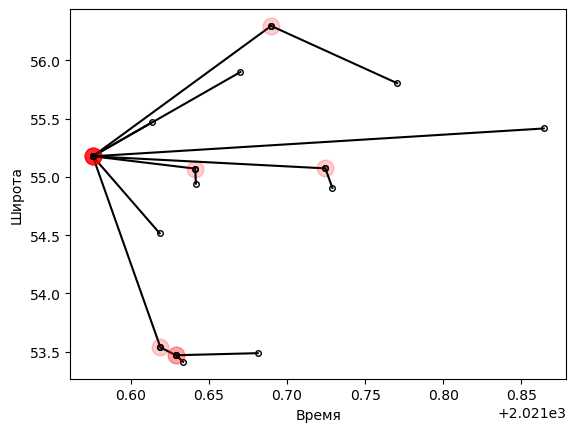

In [8]:
# ----------------------------------------------------------------------------------------------------------------------------------------------------------
# Расширяющееся дерево
# ----------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(1)
ax = plt.subplot(111)  
for iEv in range(catParent.size()):
    print(f"MS-ID, {int(catParent.data['N'][iEv]):d}, t-Par: {catParent.data['Time'][iEv]:.5f}, 't-child', {eqCat.data['Time'][iEv]:.5f}", end="\r")

    if dNND['aNND'][iEv] < dPar['eta_0']:  # триггерный кластер
        ax.plot([catParent.data['Time'][iEv]], [catParent.data['Lat'][iEv]], 'ro', ms=12, alpha=.2)
        ax.plot([catParent.data['Time'][iEv], catChild.data['Time'][iEv]],
                 [catParent.data['Lat'][iEv], catChild.data['Lat'][iEv]], 'k-', marker='o', ms=4, mew=1, mfc='none')
    else:  # независимые события
        ax.plot([catChild.data['Time'][iEv]], [catChild.data['Lat'][iEv]], 'bo', ms=5, alpha=.6)
ax.set_xlabel('Время')
ax.set_ylabel('Широта')

Синие точки на представленном выше графике представляют собой независимые фоновые события. Это означает, что их ближайший сосед находится за пределами выбранного (или рассчитанного) значения eta_0.

Красные и чёрные круги — это кластерные события, соединённые чёрными линиями.
Чем темнее красный цвет, тем больше событий связано с этим родителем.
Чёрные круги — это последнее поколение в серии триггеров, т.е. афтершоки, которые сами по себе не вызывают афтершоков.

### 3: Подсчет афтершоков и построение графика зависимости производительности атершоков

In [9]:
# -----------------------------------------------------------------------------------------
# Загрузка данных, выбор событий
# -----------------------------------------------------------------------------------------

N_tot = eqCat.size()
print( 'Общее количество событий', N_tot)

# -----------------------------------------------------------------------------------------
# Одиночные события считаются главными толчками с 0 афтершоками
# -----------------------------------------------------------------------------------------

print('Общее количество кластеров', len( dClust.keys())), 
print('Количество фоновых событий', dClust['0'].shape[0])
a_ID_single  = dClust['0']

# ID фоновых событий
a_iSel       = np.zeros( eqCat.size(), dtype = int)
a_mag_single = np.zeros( len( a_ID_single))
a_N_AS_single= np.zeros( len( a_ID_single))
a_N_FS_single= np.zeros( len( a_ID_single))
for i in range( a_ID_single.shape[0]):
    # ID события может встречаться в каталоге несколько раз
    sel_ev          = eqCat.data['N'] == a_ID_single[i]
    a_mag_single[i] = eqCat.data['Mag'][sel_ev][0]
    a_iSel[sel_ev] = 1 # catalog.data['N'][catalog.data['N']==aEqID[i]][0]
    if sel_ev.sum() != 1:
        error_str = 'Найдено более одного события', eqCat.data['N'][sel_ev]
        raise( ValueError( error_str))
    
# Удаление одиночных событий из каталога
eqCat.selDicAll( np.logical_not(a_iSel))
print('Оставшиеся события', eqCat.size()), 
print('Фоновые события', len(a_mag_single))
dClust.pop('0') # удаление одиночных событий

Общее количество событий 15
Общее количество кластеров 2
Количество фоновых событий 0
Оставшиеся события 15
Фоновые события 0


array([], dtype=float64)

In [10]:
# ------------------------------------------------------------------------------------------------------------------------
# Получение магнитуд главных толчков с афтершоками, подсчёт афтершоков
# ------------------------------------------------------------------------------------------------------------------------

a_N_FS    = np.zeros(len( dClust.keys()), dtype = int)
a_N_AS    = np.zeros(len( dClust.keys()), dtype = int)
a_MS_mag  = np.zeros(len( dClust.keys()))
a_MS_ID   = np.zeros(len( dClust.keys()), dtype = int)
iCl = 0
for sCl in dClust.keys():
    aEqID = dClust[sCl]
    print('Кластер: ', iCl+1,'из: ', len( dClust.keys()), 'Количество событий в кластере.', 
          len( aEqID), len(np.unique( dClust[sCl])), end="\r")
    
    # Нахождение магнитуды главного толчка и магнитуды всей семьи
    atmp_MAG = np.zeros(len( aEqID))
    atmp_Time= np.zeros(len( aEqID))
    a_iSel   = np.zeros(eqCat.size(), dtype = int)

    # Нахождение для каждой семьи: магнитуды события и времени возникновения
    for iM in range(len( aEqID)):
        sel_ev           = eqCat.data['N'] == aEqID[iM]
        if sel_ev.sum() != 1:
            error_str = 'Найдено более одного или ни одного события', eqCat.data['N'][sel_ev], aEqID[iM]
            raise(ValueError, error_str)
        atmp_MAG[iM]   = eqCat.data['Mag'][sel_ev][0]
        atmp_Time[iM]  = eqCat.data['Time'][sel_ev][0]
        a_iSel[sel_ev] = 1

    # Удаление событий из каталога
    # catalog.selDicAll( np.logical_not(a_iSel))

    # Главный толчок --------------------------------------------------------------- 
    selMS     = atmp_MAG == atmp_MAG.max()
    f_tMS     = atmp_Time[selMS][0]
    i_ID_MS   = aEqID[selMS]
    # print('tMS', tMS, v_currEqID.shape[0], 'MAG', curr_cat.data['MAG'][selMS][0])

    # Афтершоки -------------------------------------------------------------------- 
    selAS     = atmp_Time > f_tMS
    selFS     = atmp_Time < f_tMS
    # print('Количество афтершоков', selAS.sum()
    # Сохранение количества афтершоков для каждой магнитуды главного толчка
    a_MS_mag[iCl] = atmp_MAG[selMS][0]#, dPar['magRound'])
    a_N_AS[iCl]   = selAS.sum()
    a_N_FS[iCl]   = selFS.sum()
    a_MS_ID[iCl]  = int( i_ID_MS[0])
    iCl += 1

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------
# Сравнение главных толчков + одиночных + форшоков + афтершоков с исходным количеством событий в каталоге
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------

# Объединение одиночных событий без афтершоков с главными толчками, у которых есть афтершоки
a_N_FS    = np.append( a_N_FS, a_N_FS_single)
a_N_AS    = np.append( a_N_AS, a_N_AS_single)
a_MS_mag  = np.append( a_MS_mag, a_mag_single)
a_MS_ID   = np.append( a_MS_ID, a_ID_single)
print('Всего событий в каталоге', N_tot,)
print('Всего событий в семьях',a_N_FS.sum() + a_N_AS.sum() + a_MS_mag.shape[0])
#print('Фоновые события', a_mag_single.shape[0], 'Форшоки', a_N_FS_single.sum(), 'Афтершоки', a_N_AS_single.sum(), 'Главные толчки (MS+BG)', a_MS_mag.shape[0]

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------
# Сохранение в текстовый файл ASCII
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------
file_out = '%s/%s_Nas_MS_Mc_%.1f.txt'%(dir_in, file_in.split('.')[0], dPar['Mc'])#, dPar['magRound'])
m_N_as   = np.array([a_MS_mag, a_N_AS, a_N_FS, a_MS_ID])
np.savetxt(f"data/{file_out}", m_N_as.T, fmt='%10.3f%10i%10i%14i',
            header = 'MAG          N-AS          N-FS        MS-ID; note N_AS=0 highlights singles or FS only')

Всего событий в каталоге 15во событий в кластере. 15 15
Всего событий в семьях 15.0


Два числа выше должны совпадать, в противном случае, возможно, придется перезапустить код с самого начала.

Магнитуда: 6.9, Среднее N-АФТЕРШОКОВ: 14.0, 20-й процентиль: 14.0, 80-й процентиль: 14.0, Количество семей: 1.0


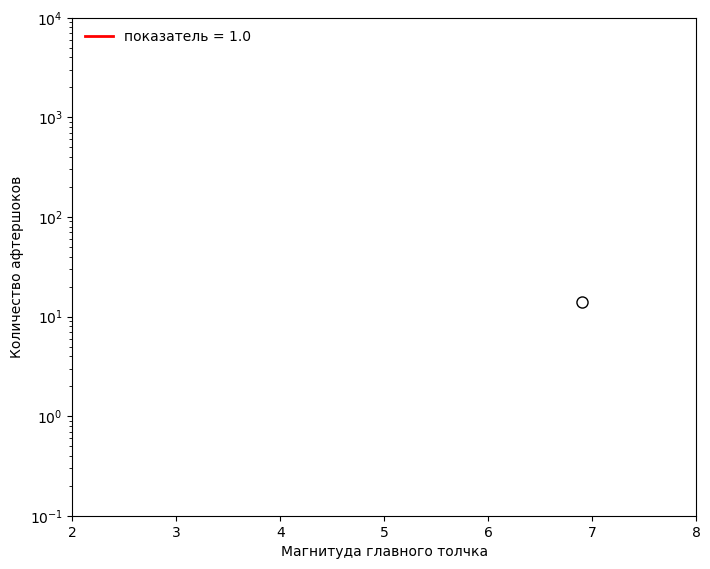

In [11]:
dPar['magRound'] = 1  # биннинг

# Построение графиков --------------------------------------------------------------------==------------------- 
dPar['alpha'] = 1.0  # показатель степени закона
dPar['xmin'] = 2
dPar['xmax'] = 8
dPar['ymin'] = 0.1
dPar['ymax'] = 1e4

# -------------------------------------------------------------------------------------------------------------
# Подсчёт среднего количества афтершоков для магнитуды главного толчка
# -------------------------------------------------------------------------------------------------------------

aMag_round = np.around(m_N_as[0], dPar['magRound'])
aMag_bin = np.array(sorted(np.unique(aMag_round)))
aAveNo_AS = np.ones(len(aMag_bin)) * np.nan
aNo_Fam = np.zeros(len(aMag_bin))  # общее количество семей в бине магнитуды
aNo_AS20 = np.zeros(len(aMag_bin))
aNo_AS80 = np.zeros(len(aMag_bin))

i = 0
for curr_mag in aMag_bin:
    selMag = curr_mag == aMag_round
    aAveNo_AS[i] = m_N_as[1][selMag].mean()
    if selMag.sum() > 0:
        aNo_AS20[i] = np.percentile(m_N_as[1][selMag], 20)
        aNo_AS80[i] = np.percentile(m_N_as[1][selMag], 80)
    aNo_Fam[i] = selMag.sum()
    print(f"Магнитуда: {curr_mag}, Среднее N-АФТЕРШОКОВ: {round(aAveNo_AS[i], 2)}, "
          f"20-й процентиль: {aNo_AS20[i]}, 80-й процентиль: {aNo_AS80[i]}, "
          f"Количество семей: {aNo_Fam[i]}")
    i += 1

# -------------------------------------------------------------------------------------------------------------
# Построение закона продуктивности
# -------------------------------------------------------------------------------------------------------------

plt.figure(1, figsize=(8, 6))
ax = plt.axes([0.14, 0.12, 0.78, 0.83])  # pPlot.createFigureSquare(1)
ax.semilogy(m_N_as[0], m_N_as[1], 'o', ms=6, mew=0, mfc='.7', alpha=0.2)
yerr_low = np.maximum(0, aAveNo_AS - aNo_AS20)
yerr_high = np.maximum(0, aNo_AS80 - aAveNo_AS)
ax.errorbar(aMag_bin, aAveNo_AS, yerr=[yerr_low, yerr_high],
            fmt='o', ecolor='k', elinewidth=0.7, capsize=2.5, mec='k', ms=8, mew=1, mfc='w')

# Экспоненциальная оценка -------------------------------------------------------------------------------------
mag_fit = aMag_bin[min(4, len(aMag_bin) - 1)]  # принудительная подгонка через эту точку
f_no_AS_pl = aAveNo_AS[aMag_bin == mag_fit]
preFac = np.log10(f_no_AS_pl) - dPar['alpha'] * mag_fit
a_N_hat = 10 ** (dPar['alpha'] * aMag_bin + preFac)
ax.semilogy(aMag_bin, a_N_hat, 'w-')
ax.semilogy(aMag_bin, a_N_hat, '-', color='r', lw=2, label='показатель = %.1f' % (np.round(dPar['alpha'], 1)))

# Подписи, пределы и т.д. -------------------------------------------------------------------------------------
ax.set_xlim(dPar['xmin'], dPar['xmax'])
ax.set_ylim(dPar['ymin'], dPar['ymax'])
ax.set_xlabel('Магнитуда главного толчка')
ax.set_ylabel('Количество афтершоков')
ax.legend(loc='upper left', frameon=False);

Ошибка: Размер dNND['aNND'] (14) не соответствует размеру каталога (15).
Синхронизируем dNND с текущим каталогом...


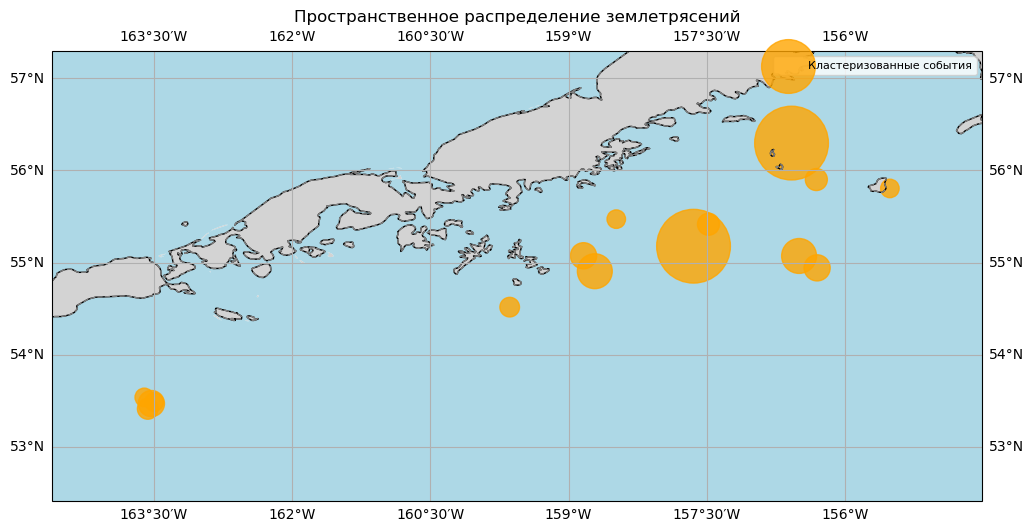

In [12]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------
# Визуализация кластеров на географической карте
# -------------------------------------------------------------------------------------------------------------------------------------------------------------

# Синхронизация dNND с текущим каталогом
if len(dNND['aNND']) != len(eqCat.data['Lon']):
    print(f"Ошибка: Размер dNND['aNND'] ({len(dNND['aNND'])}) не соответствует размеру каталога ({len(eqCat.data['Lon'])}).")
    print("Синхронизируем dNND с текущим каталогом...")
    sel_valid = np.isin(dNND['aEqID_c'], eqCat.data['N'])
    if not np.any(sel_valid):
        print("Ошибка: Нет совпадений между dNND['aEqID_c'] и eqCat.data['N']. Проверьте данные.")
        raise ValueError("Нет совпадений идентификаторов.")
    dNND = {
        'aNND': dNND['aNND'][sel_valid],
        'aEqID_p': dNND['aEqID_p'][sel_valid],
        'aEqID_c': dNND['aEqID_c'][sel_valid],
        'Time': dNND['Time'][sel_valid]
    }

valid_nnd = dNND['aNND'] > 0
dNND['aNND'] = np.maximum(dNND['aNND'], 1e-10)
valid_nnd = dNND['aNND'] > 0

sel_clust = np.zeros_like(dNND['aNND'], dtype=bool)
sel_clust[valid_nnd] = np.log10(dNND['aNND'][valid_nnd]) < dPar['eta_0']  # Булев массив для кластеризованных событий

# Синхранизация dClust с текущим каталогом
for famID in list(dClust.keys()):
    indices = dClust[famID]
    valid_indices = np.isin(indices, eqCat.data['N'])
    dClust[famID] = indices[valid_indices]
    if len(dClust[famID]) == 0:
        print(f"Предупреждение: Кластер {famID} пуст после синхронизации. Удаляем его.")
        del dClust[famID]

num_clusters = len(dClust)

# Создание фигуры с географической проекцией
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())  # Простая географическая проекция

# Добавление географических элементов
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')

# Установление границ карты
lon_min, lon_max = eqCat.data['Lon'].min() - 1, eqCat.data['Lon'].max() + 1
lat_min, lat_max = eqCat.data['Lat'].min() - 1, eqCat.data['Lat'].max() + 1
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Отображение всех кластеризованных событий
for i, (famID, indices) in enumerate(dClust.items()):
    if len(indices) > 0:
        sel_indices = np.isin(eqCat.data['N'], indices)
        ax.scatter(eqCat.data['Lon'][sel_indices], eqCat.data['Lat'][sel_indices],
                   s=10**(eqCat.data['Mag'][sel_indices]/2),  # Размер маркера зависит от магнитуды
                   c='orange', alpha=0.8, label='Кластеризованные события' if i == 0 else None,
                   transform=ccrs.PlateCarree())

ax.set_title('Пространственное распределение землетрясений')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()